In [1]:
import numpy as np
from numpy import pi, arccos, cos, sin, tan, mean
import matplotlib.pyplot as plt
#from cats.cdataframe import CDataFrame
import glob
import pandas as pd

In [2]:
#colors = {'0V': {'h': '#4376B6',
#                 'e': '#D72B22'},
#          '4V': {'h': '#92C0DC',
#                   'e': '#FC8D57'}}

colors = {'4V': {'h': '#D72B22',
                 'e': '#FC8D57'},
          '0V': {'h': '#3D6CA5',
                   'e': '#92C0DC'}}

label = {'0V': {'h': r'$\mathbf{holes}$ at $\mathbf{0V}$',
                 'e': r'$\mathbf{electrons}$ at $\mathbf{0V}$'},
          '4V': {'h': r'$\mathbf{holes}$ at $\mathbf{4V}$',
                   'e': r'$\mathbf{electrons}$ at $\mathbf{4V}$'}}

In [3]:
h     = 4.13566e-12 # MeV*ns
hbar  = h / (2 * np.pi) # MeV*ns
mass = {'h': 0.50 * 0.51099906 / (2.99792458 * 1e2)**2,
        'e': 1.4672e-6} # MeV ns^2 / mm^2
vsound = 0.009 # mm/ns # Longitudinal sound speed

ksound = {'h': mass['h'] * vsound / hbar,
          'e': mass['e'] * vsound / hbar}

In [4]:
Vs = ['0V', '4V']
charges = ['h', 'e']

phononData = {V: {charge: None for charge in charges} for V in Vs}
chargeData = {V: {charge: None for charge in charges} for V in Vs}
scatterData = {V: {charge: None for charge in charges} for V in Vs}

In [7]:
for V in Vs:
    for charge in charges:
        phononData[V][charge] = pd.read_csv(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/phonon.csv')
        chargeData[V][charge] = pd.read_csv(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/charge.csv')
        scatterData[V][charge] = pd.read_csv(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/scatter.csv')

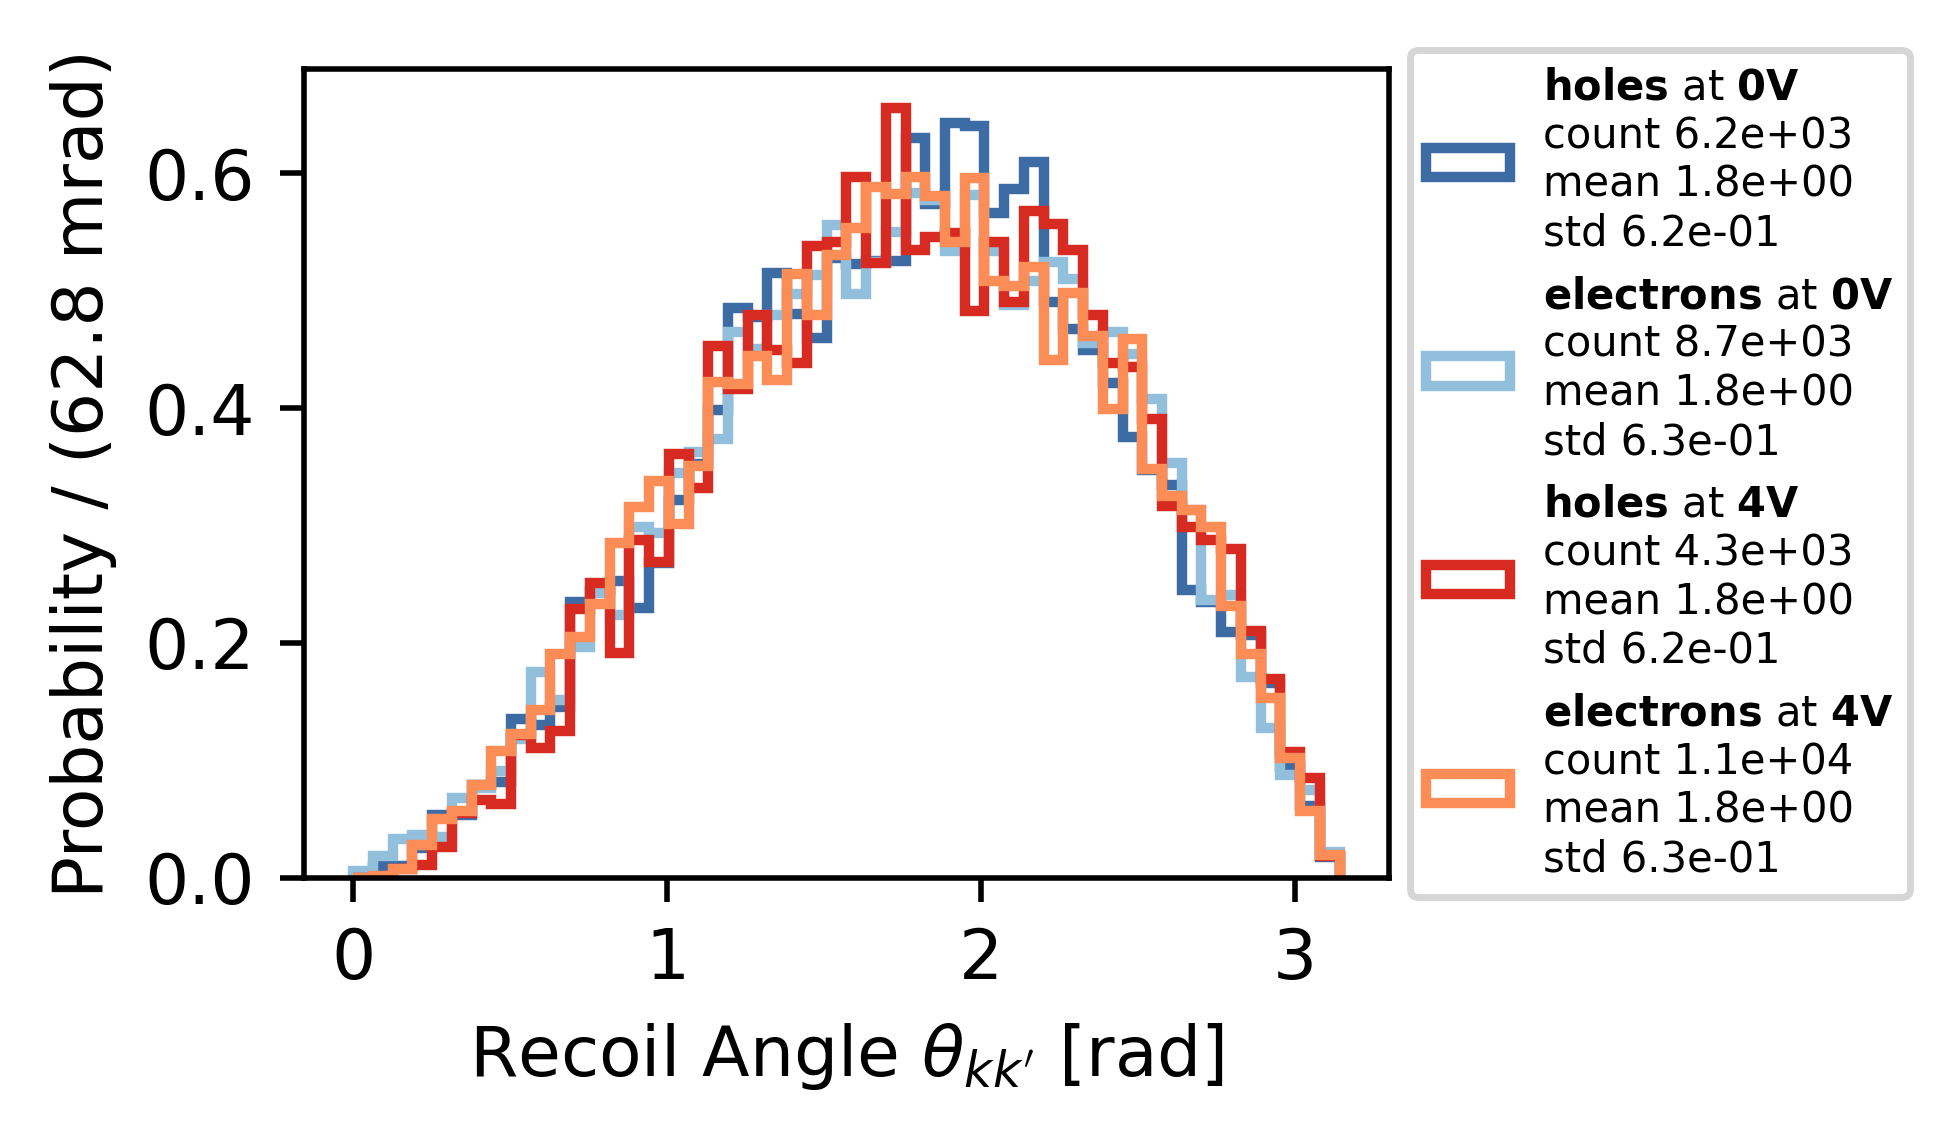

In [8]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
    
        ax.hist(scatterData[V][charge]['Recoil Theta'], bins = np.linspace(0, pi, 51), 
                 label = (label[V][charge] + "\n" + f"count {len(scatterData[V][charge]['Recoil Theta']):.1e}" + "\n" + 
                          f"mean {np.nanmean(scatterData[V][charge]['Recoil Theta']):.1e}" +'\n'+
                          f"std {np.nanstd(scatterData[V][charge]['Recoil Theta']):.1e}"), 
                 histtype='step', color=colors[V][charge], linewidth=1.5, density = True)

ax.set_xlabel('Recoil Angle ' + r"$\theta_{kk'}$" + ' [rad]')
ax.set_ylabel('Probability / (62.8 mrad)')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

#plt.tight_layout()
#plt.savefig('figures/recoil_angle')

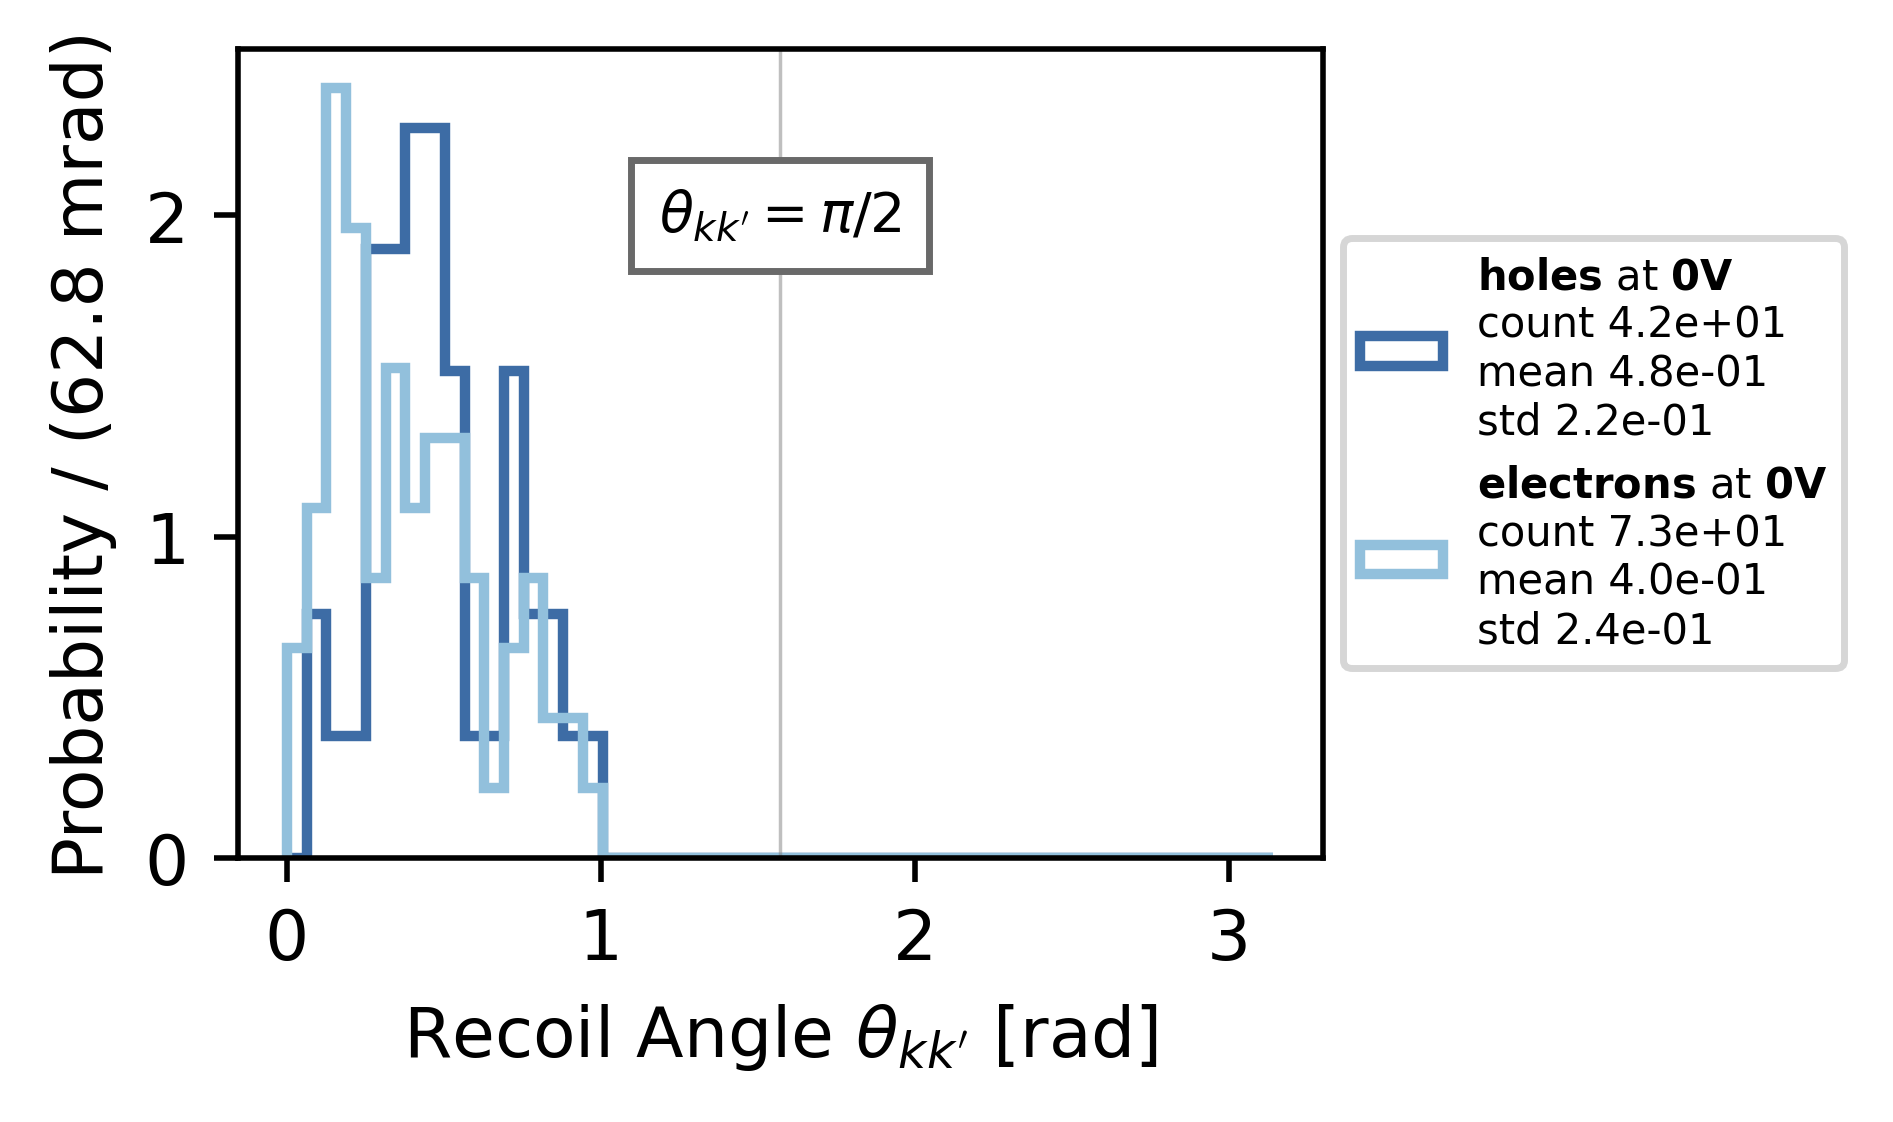

In [9]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        k_cut = scatterData[V][charge]['WaveVector'] < 2 * ksound[charge]
        ax.hist(scatterData[V][charge]['Recoil Theta'][k_cut], bins = np.linspace(0, pi, 51), 
                 label = (label[V][charge] + "\n" + f"count {len(scatterData[V][charge]['Recoil Theta'][k_cut]):.1e}" + "\n" + 
                          f"mean {np.nanmean(scatterData[V][charge]['Recoil Theta'][k_cut]):.1e}" +'\n'+
                          f"std {np.nanstd(scatterData[V][charge]['Recoil Theta'][k_cut]):.1e}"), 
                 histtype='step', color=colors[V][charge], linewidth=1.5, density = True)

ax.axvline(90 / 180 * pi, 0, 1, ls = '-', color = 'grey', lw=0.5, alpha = 0.5)
ax.text(90 / 180 * pi, 2, r"$\theta_{kk'} = \pi / 2$", bbox=dict(facecolor='white', edgecolor='dimgrey'), 
        horizontalalignment='center', verticalalignment='center', fontsize=8)

ax.set_xlabel('Recoil Angle ' + r"$\theta_{kk'}$" + ' [rad]')
ax.set_ylabel('Probability / (62.8 mrad)')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

#plt.tight_layout()
#plt.savefig('figures/recoil_angle')

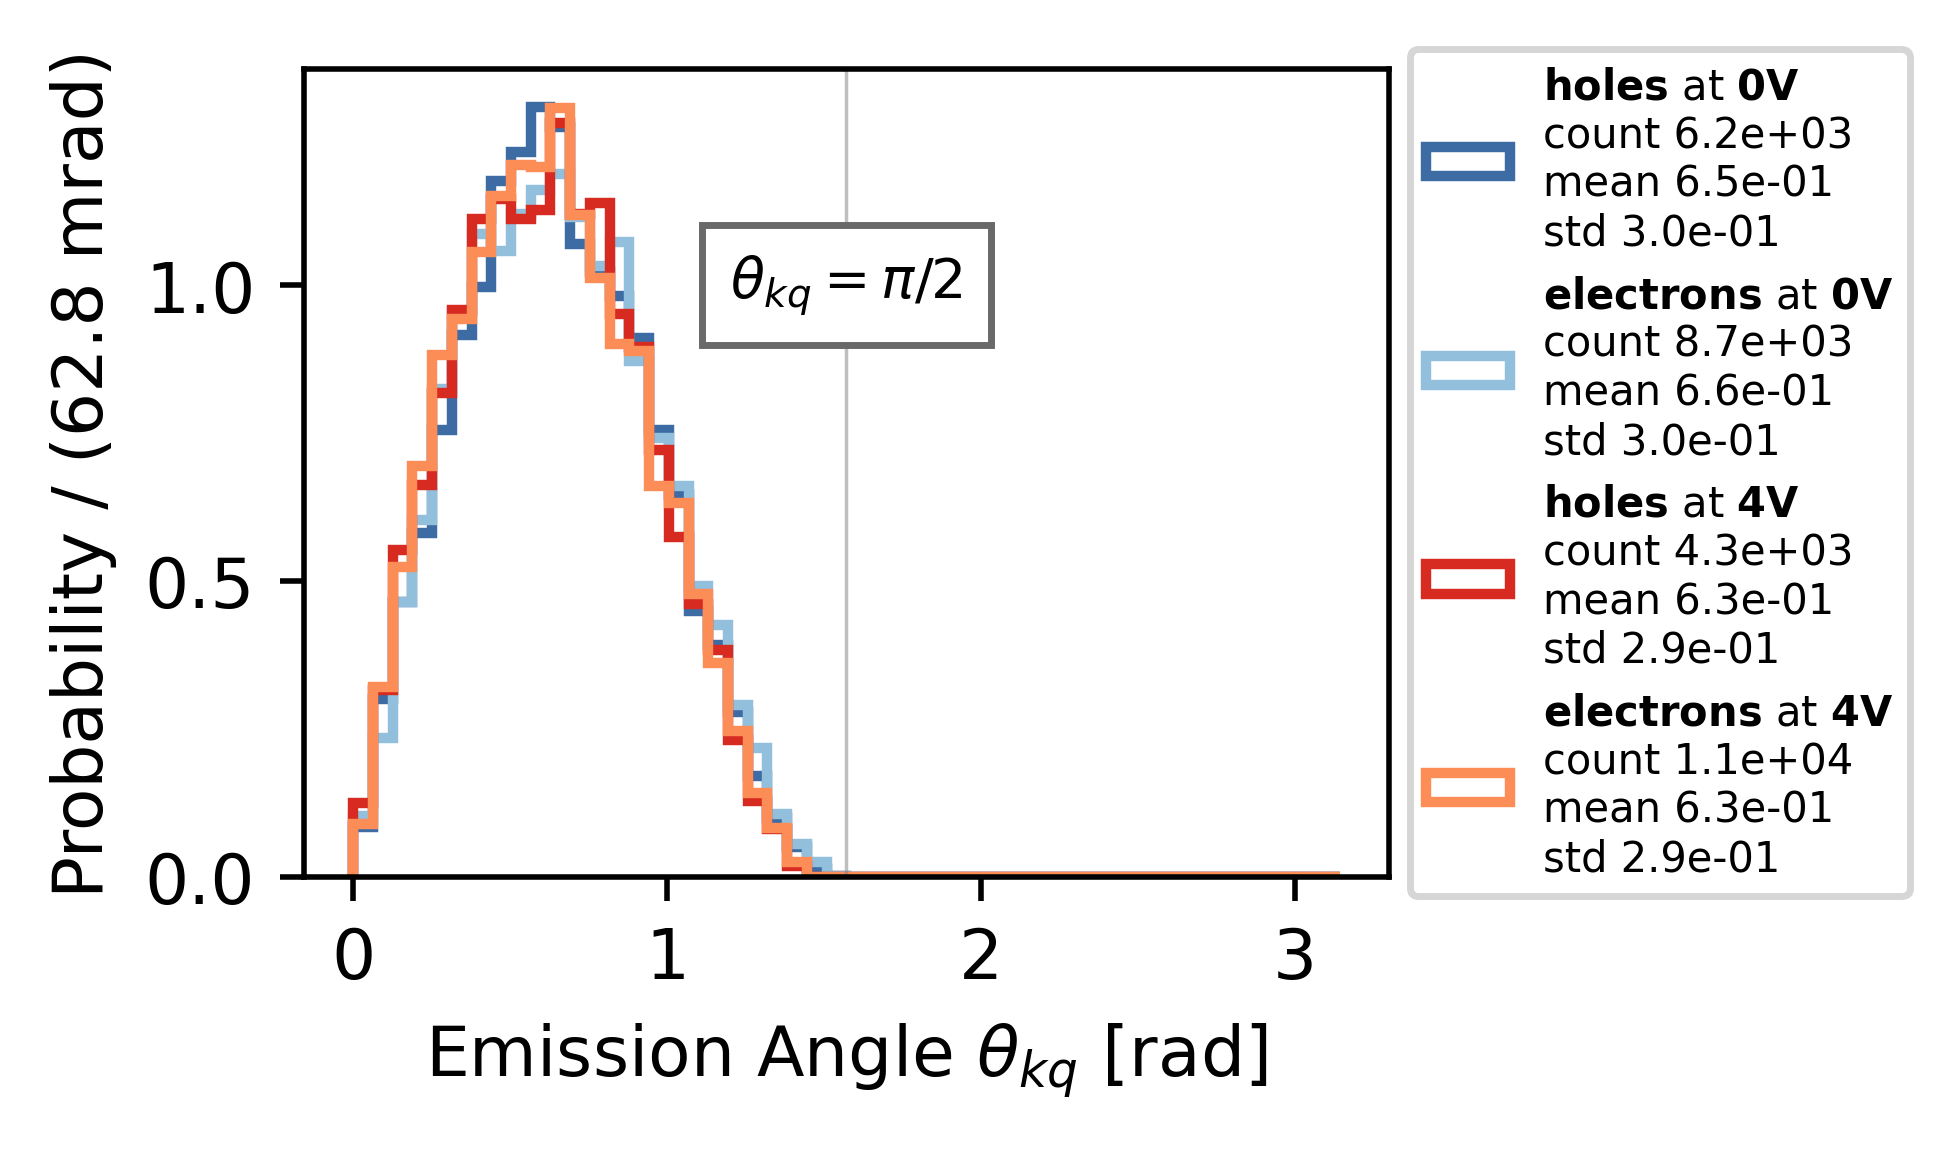

In [10]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
    
        ax.hist(scatterData[V][charge]['Phonon Theta'], bins = np.linspace(0, pi, 51), 
             label = (label[V][charge] + "\n" + f"count {len(scatterData[V][charge]['Phonon Theta']):.1e}" + "\n" + 
                      f"mean {np.nanmean(scatterData[V][charge]['Phonon Theta']):.1e}" +'\n'+
                      f"std {np.nanstd(scatterData[V][charge]['Phonon Theta']):.1e}"), 
             histtype='step', color=colors[V][charge], linewidth=1.5, density=True)

ax.axvline(90 / 180 * pi, 0, 1, ls = '-', color = 'grey', lw=0.5, alpha = 0.5)
ax.text(90 / 180 * pi, 1, r'$\theta_{kq} = \pi / 2$', bbox=dict(facecolor='white', edgecolor='dimgrey'), 
        horizontalalignment='center', verticalalignment='center', fontsize=8)

ax.set_xlabel('Emission Angle ' + r"$\theta_{kq}$" + ' [rad]')
ax.set_ylabel('Probability / (62.8 mrad)')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

#ax.tight_layout()
#plt.savefig('figures/emission_angle')

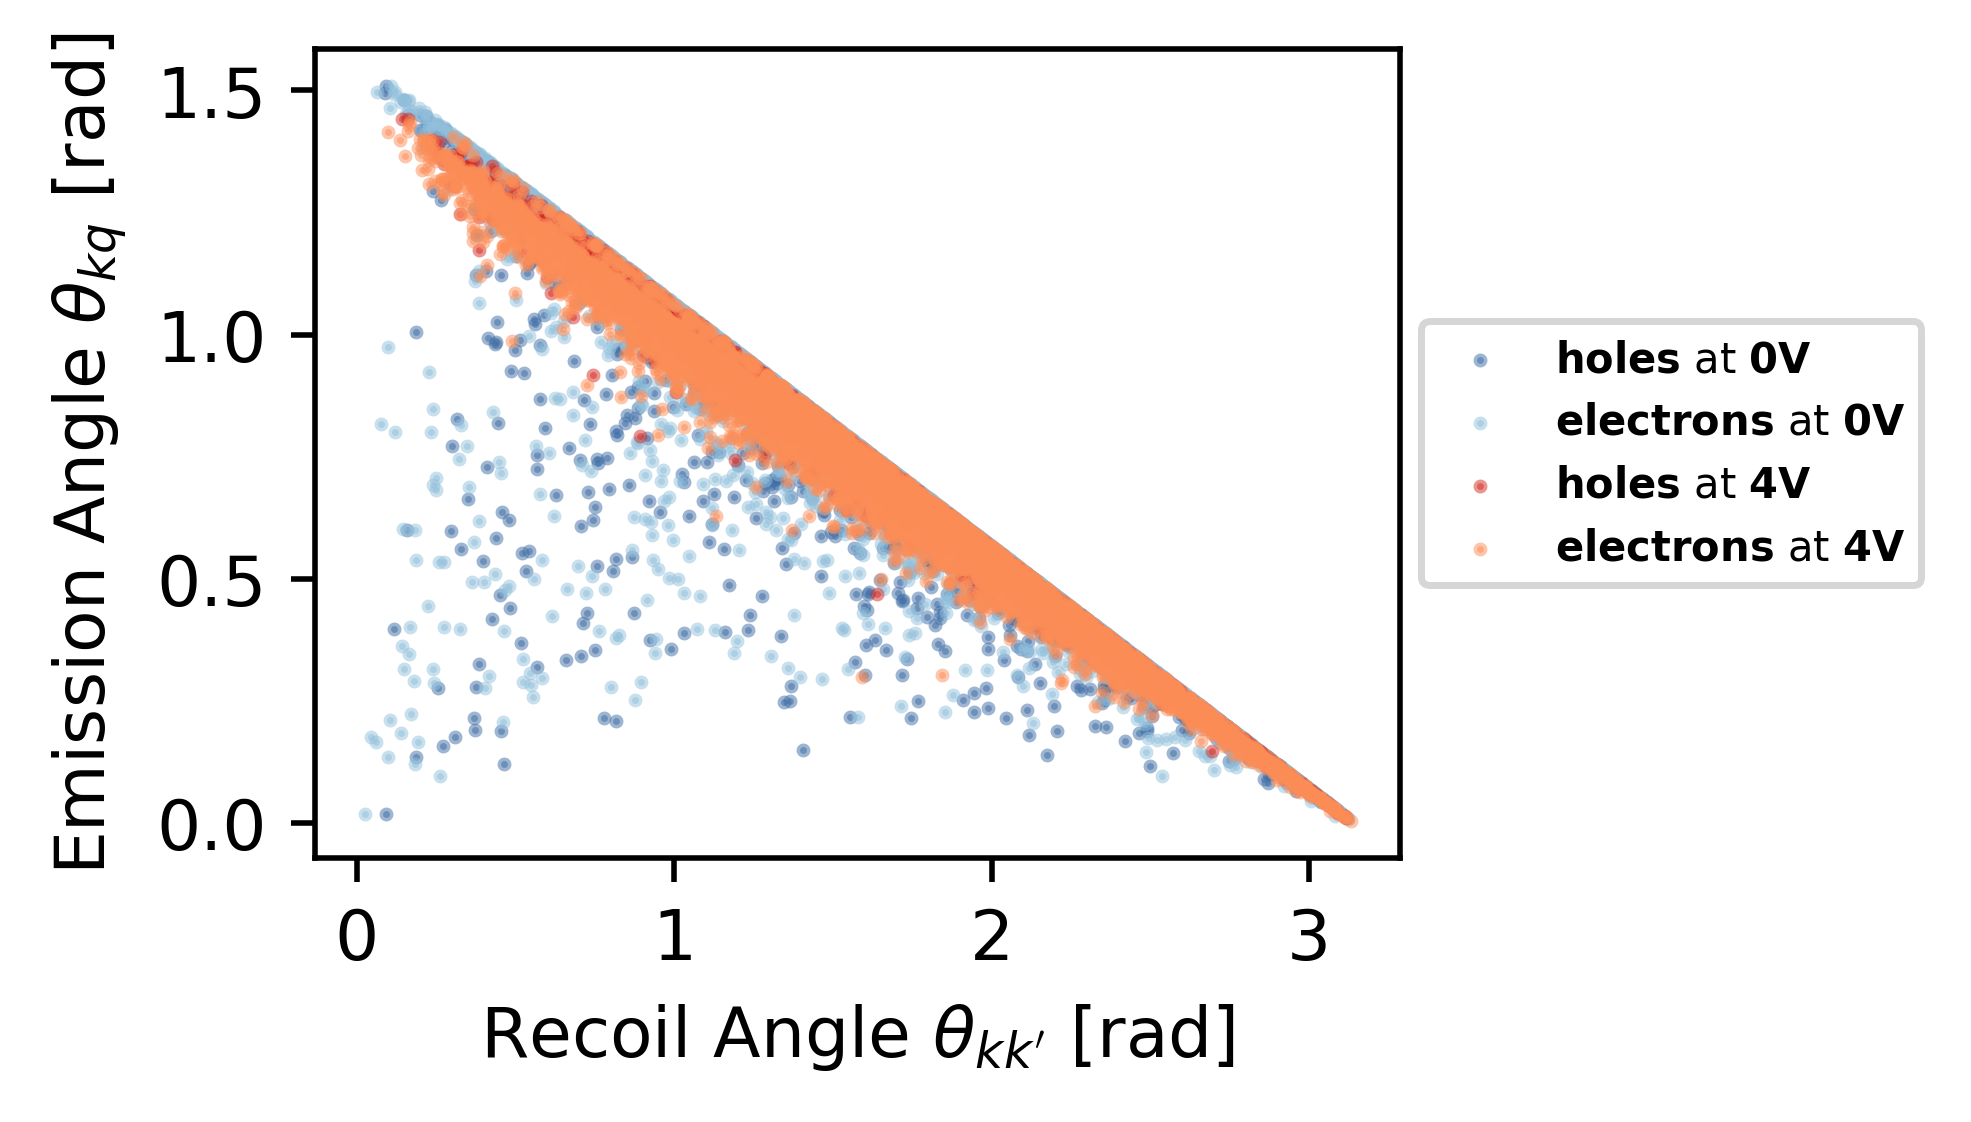

In [12]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
    
        ax.scatter(scatterData[V][charge]['Recoil Theta'], scatterData[V][charge]['Phonon Theta'], s=1, 
             label = label[V][charge], color=colors[V][charge], alpha = 0.5)

ax.set_xlabel('Recoil Angle ' + r"$\theta_{kk'}$" + ' [rad]')
ax.set_ylabel('Emission Angle ' + r"$\theta_{kq}$" + ' [rad]')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

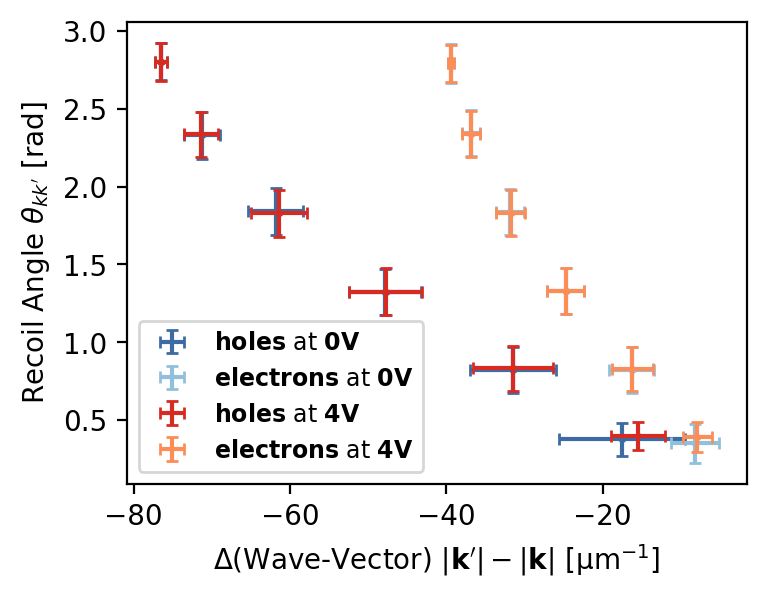

In [16]:
plt.figure(figsize=(4,3), dpi = 200)

theta_bins = np.arange(0, pi + pi/6, pi/6)

for V in Vs:
    for charge in charges:
        theta_mean, theta_std = [], []
        KE_mean, KE_std = [], []
        for step in range(len(theta_bins)):
            theta_cut = (scatterData[V][charge]['Recoil Theta'] > theta_bins[step - 1]) & (scatterData[V][charge]['Recoil Theta'] < theta_bins[step])
            theta_mean.append(np.mean(scatterData[V][charge]['Recoil Theta'][theta_cut]))
            theta_std.append(np.std(scatterData[V][charge]['Recoil Theta'][theta_cut]))
            KE_mean.append(np.mean((scatterData[V][charge]['Recoil WaveVector'] - scatterData[V][charge]['WaveVector'])[theta_cut]))
            KE_std.append(np.std((scatterData[V][charge]['Recoil WaveVector'] - scatterData[V][charge]['WaveVector'])[theta_cut]))

        KE_mean, KE_std = np.array(KE_mean)*1e-3, np.array(KE_std)*1e-3
        theta_mean, theta_std = np.array(theta_mean), np.array(theta_std)

        plt.errorbar(KE_mean, theta_mean, xerr = KE_std, yerr = theta_std, ls = "None", 
            color=colors[V][charge], capsize = 2, label = label[V][charge])
        plt.scatter(KE_mean, theta_mean, s = 3, marker = "h", color = colors[V][charge])

plt.ylabel("Recoil Angle" + r" $\theta_{kk'}$ [rad]")
plt.xlabel(r"$\Delta$(Wave-Vector) $|\mathbf{k'}| - |\mathbf{k}|$ [$\mathrm{\mu m^{-1}}$]")
plt.legend(loc = 'lower left', fontsize = 8.5)

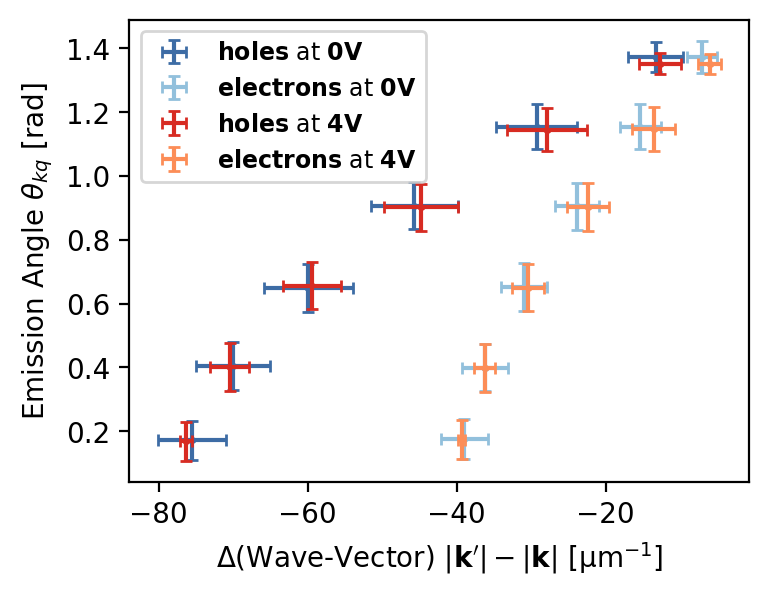

In [17]:
plt.figure(figsize=(4,3), dpi = 200)

theta_bins = np.arange(0, pi/2 + pi/12, pi/12)

for V in Vs:
    for charge in charges:
        theta_mean, theta_std = [], []
        KE_mean, KE_std = [], []
        for step in range(len(theta_bins)):
            theta_cut = (scatterData[V][charge]['Phonon Theta'] > theta_bins[step - 1]) & (scatterData[V][charge]['Phonon Theta'] < theta_bins[step])
            theta_mean.append(np.mean(scatterData[V][charge]['Phonon Theta'][theta_cut]))
            theta_std.append(np.std(scatterData[V][charge]['Phonon Theta'][theta_cut]))
            KE_mean.append(np.mean((scatterData[V][charge]['Recoil WaveVector'] - scatterData[V][charge]['WaveVector'])[theta_cut]))
            KE_std.append(np.std((scatterData[V][charge]['Recoil WaveVector'] - scatterData[V][charge]['WaveVector'])[theta_cut]))

        KE_mean, KE_std = np.array(KE_mean)*1e-3, np.array(KE_std)*1e-3
        theta_mean, theta_std = np.array(theta_mean), np.array(theta_std)

        plt.errorbar(KE_mean, theta_mean, xerr = KE_std, yerr = theta_std, ls = "None", 
            color=colors[V][charge], capsize = 2, label = label[V][charge])
        plt.scatter(KE_mean, theta_mean, s = 3, marker = "h", color = colors[V][charge])

plt.ylabel("Emission Angle" + r" $\theta_{kq}$ [rad]")
plt.xlabel(r"$\Delta$(Wave-Vector) $|\mathbf{k'}| - |\mathbf{k}|$ [$\mathrm{\mu m^{-1}}$]")
plt.legend(loc = 'upper left', fontsize = 8.5)